# ML Final Lab Project — Bank Marketing Dataset
**Master in Data Science — Machine Learning (UPC - FIB) 2026**

**Team members:** _(fill in)_

**Objective:** Predict whether a client subscribes to a term deposit (`y`) using a complete ML pipeline.

---

## 0. Setup & Imports

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer

# Unsupervised
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# Linear Models
from sklearn.linear_model import LogisticRegression, Ridge, Lasso

# Kernel Methods
from sklearn.svm import SVC

# Ensemble Methods
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Baseline
from sklearn.dummy import DummyClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


---
## 1. Exploratory Data Analysis (EDA)

### 1.1 Load Data

In [3]:
df = pd.read_csv('Bank_Marketing_Dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,management,single,tertiary,no,444,yes,no,unknown,28,may,177,17,-1,0,unknown,no
1,37,technician,married,secondary,no,787,yes,no,cellular,1,feb,106,1,-1,0,unknown,no
2,71,retired,married,secondary,no,2715,no,no,telephone,13,aug,683,4,-1,0,unknown,no
3,84,retired,divorced,primary,no,12088,no,no,telephone,12,dec,130,3,-1,0,unknown,yes
4,55,retired,married,unknown,no,161,no,no,cellular,8,jul,98,1,-1,0,unknown,no


### 1.2 Basic Info & Missing Values

In [4]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Descriptive Statistics ===')
df.describe(include='all')

=== Data Types ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

=== Descriptive Statistics ===


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,technician,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,10404,20415,21598,42607,NaN,26930,40459,30153,NaN,14175,NaN,NaN,NaN,NaN,34464,37281
mean,40.909425,NaN,NaN,NaN,NaN,1500.773086,NaN,NaN,NaN,15.841654,NaN,313.685364,3.066532,52.852094,0.707350,NaN,NaN
std,11.380169,NaN,NaN,NaN,NaN,2852.584799,NaN,NaN,NaN,8.001934,NaN,269.218336,3.288844,106.422095,1.791159,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-4290.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,31.000000,NaN,NaN,NaN,NaN,130.000000,NaN,NaN,NaN,9.000000,NaN,127.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,40.000000,NaN,NaN,NaN,NaN,593.000000,NaN,NaN,NaN,16.000000,NaN,242.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1642.500000,NaN,NaN,NaN,21.000000,NaN,408.000000,4.000000,0.000000,0.000000,NaN,NaN


### 1.3 Target Variable — Class Imbalance

y
no     37281
yes     7930
Name: count, dtype: int64

Imbalance ratio: 4.70:1


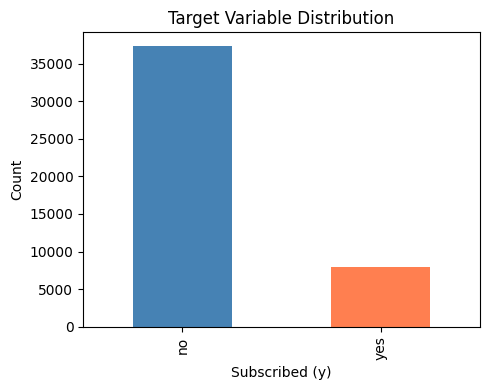

In [5]:
counts = df['y'].value_counts()
print(counts)
print(f'\nImbalance ratio: {counts[0]/counts[1]:.2f}:1')

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Variable Distribution')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 1.4 Numerical Features Distribution

Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


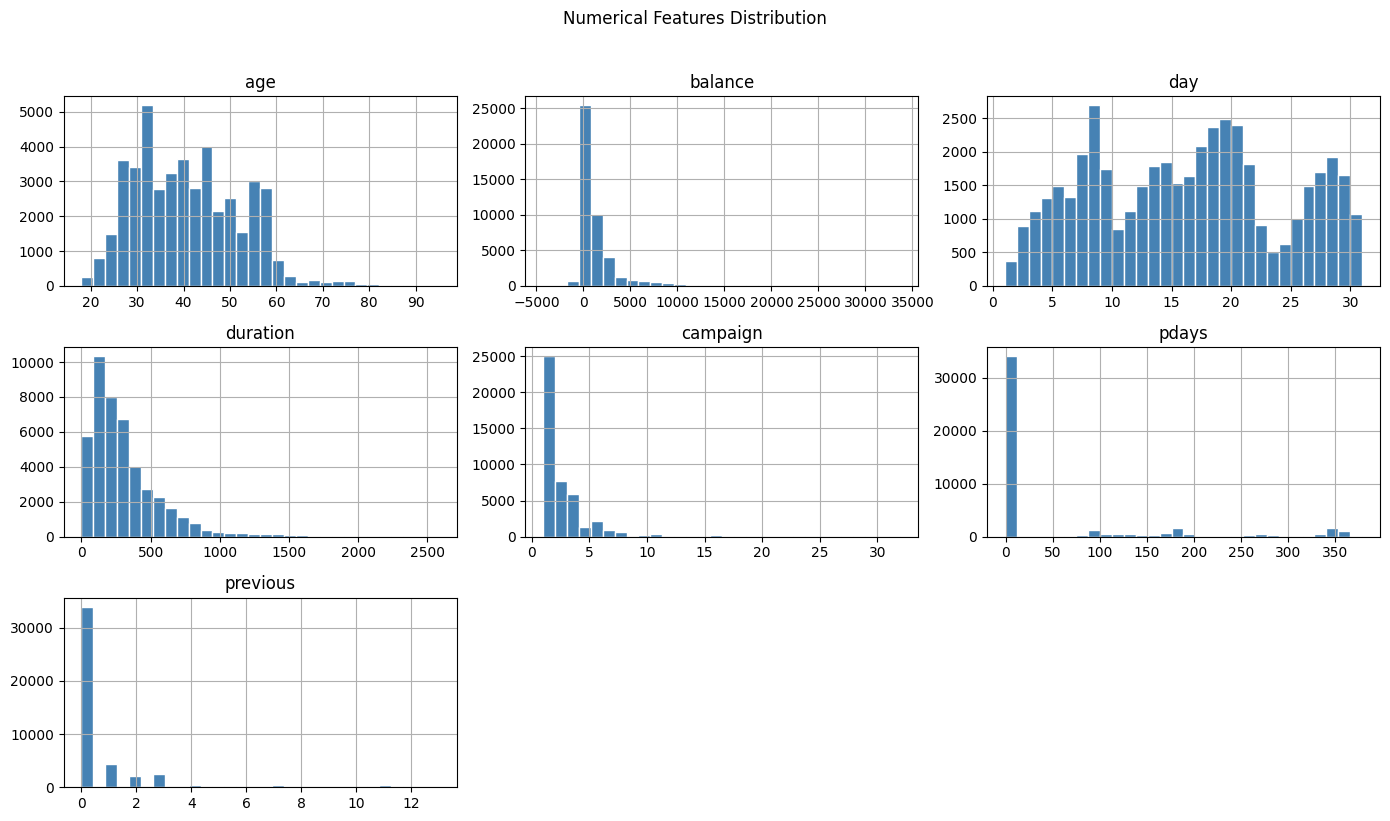

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f'Numerical columns: {num_cols}')

df[num_cols].hist(figsize=(14, 8), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Numerical Features Distribution', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Categorical Features

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


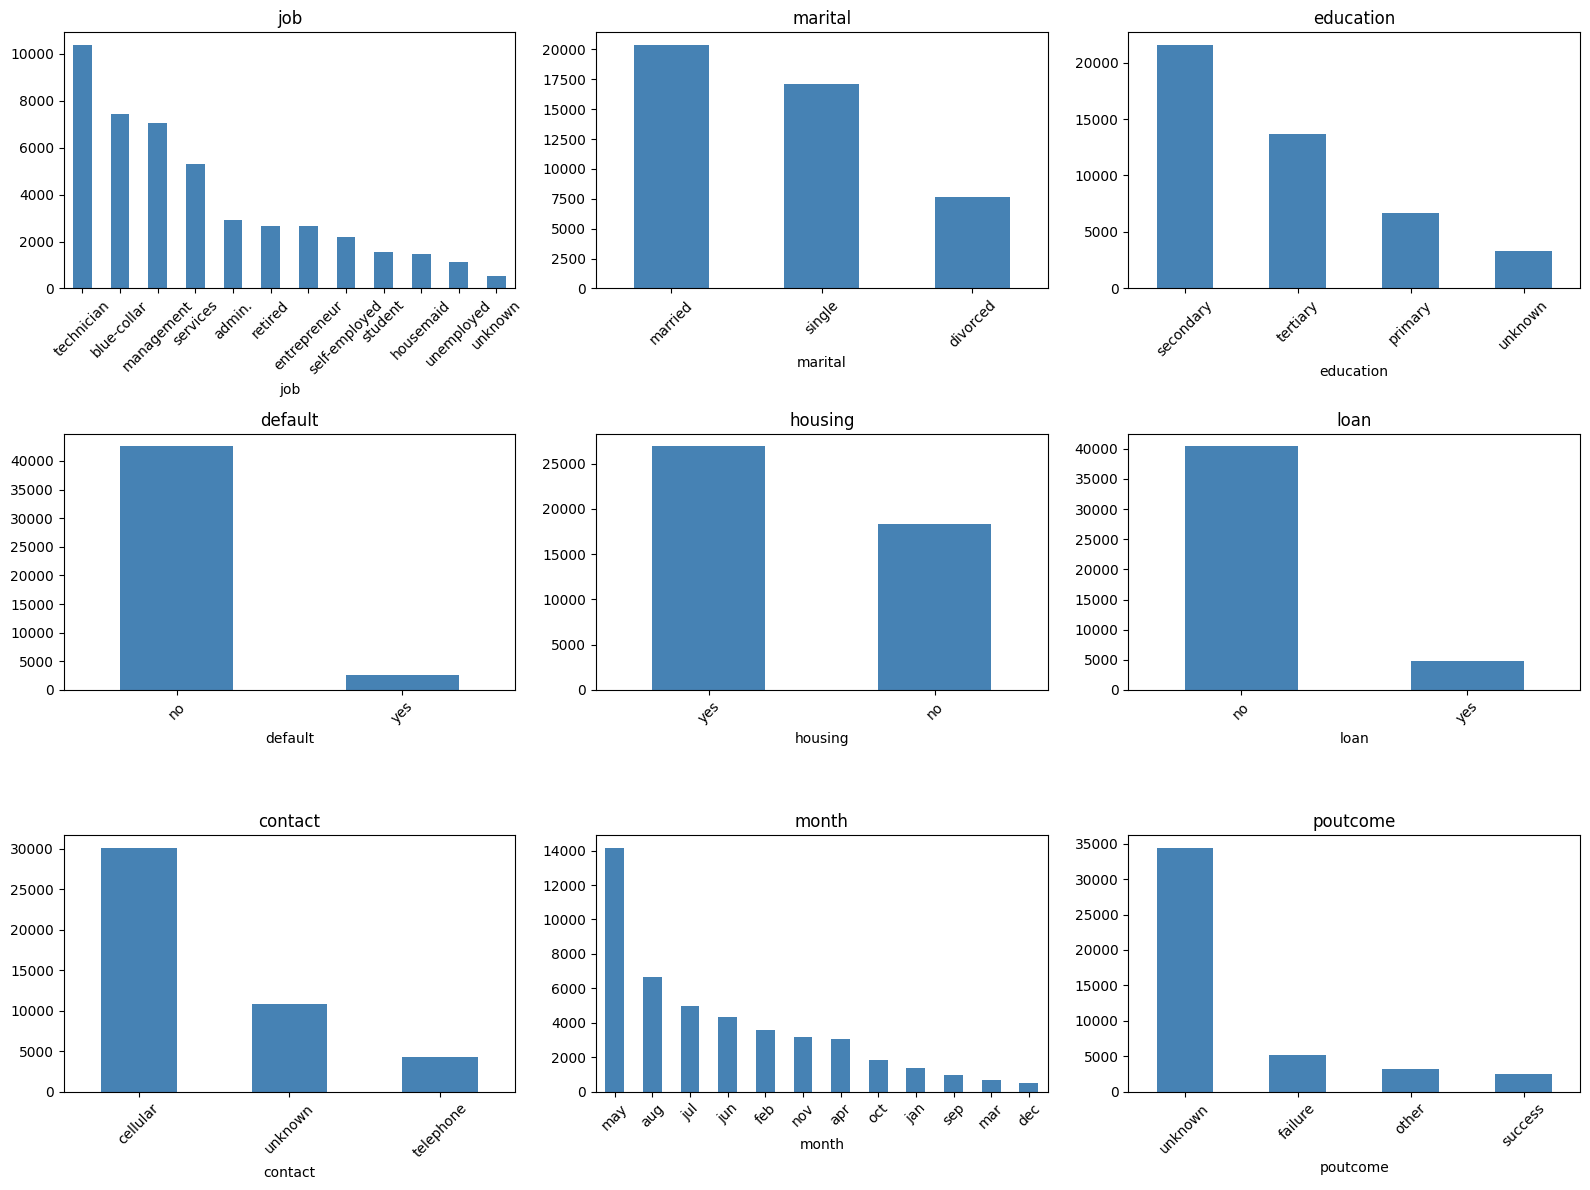

In [7]:
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()
print(f'Categorical columns: {cat_cols}')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

### 1.6 Correlation Heatmap (Numerical)

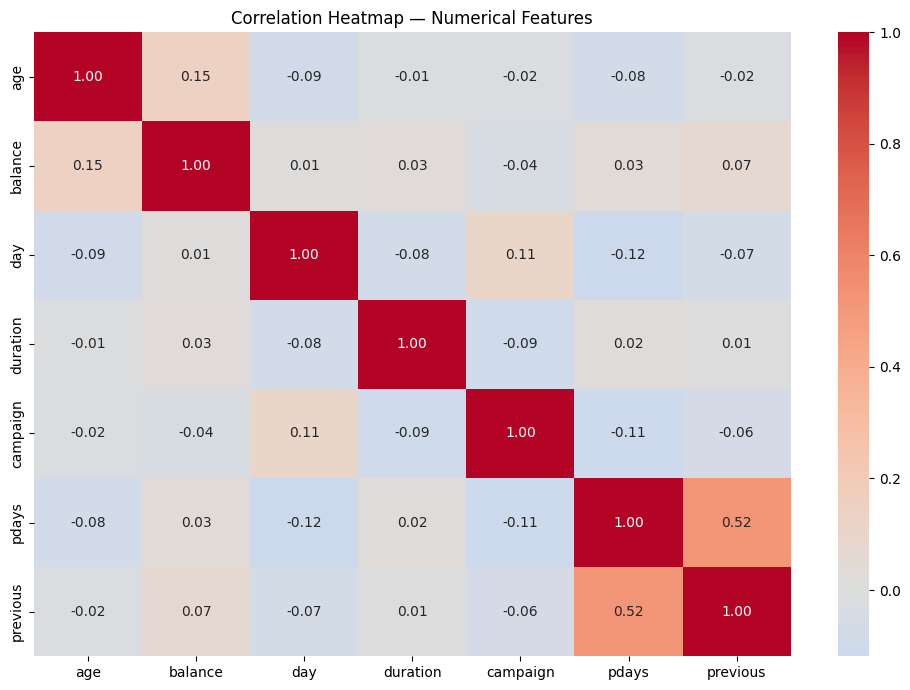

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

---
## 2. Data Preprocessing

### 2.1 Encode Target

In [9]:
df['y_enc'] = (df['y'] == 'yes').astype(int)
X = df.drop(columns=['y', 'y_enc'])
y = df['y_enc']
print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Positive class rate: {y.mean():.3f}')

X shape: (45211, 16) | y shape: (45211,)
Positive class rate: 0.175


### 2.2 Build Preprocessing Pipeline

In [10]:
# Identify feature types
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

print(f'Numerical: {num_features}')
print(f'Categorical: {cat_features}')

# Pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

print('Preprocessor built.')

Numerical: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Preprocessor built.


### 2.3 Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Fit preprocessor on train, transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Train: {X_train_proc.shape} | Test: {X_test_proc.shape}')

Train: (36168, 51) | Test: (9043, 51)


---
## Phase I — Unsupervised Structural Analysis

### I.1 PCA — Explained Variance

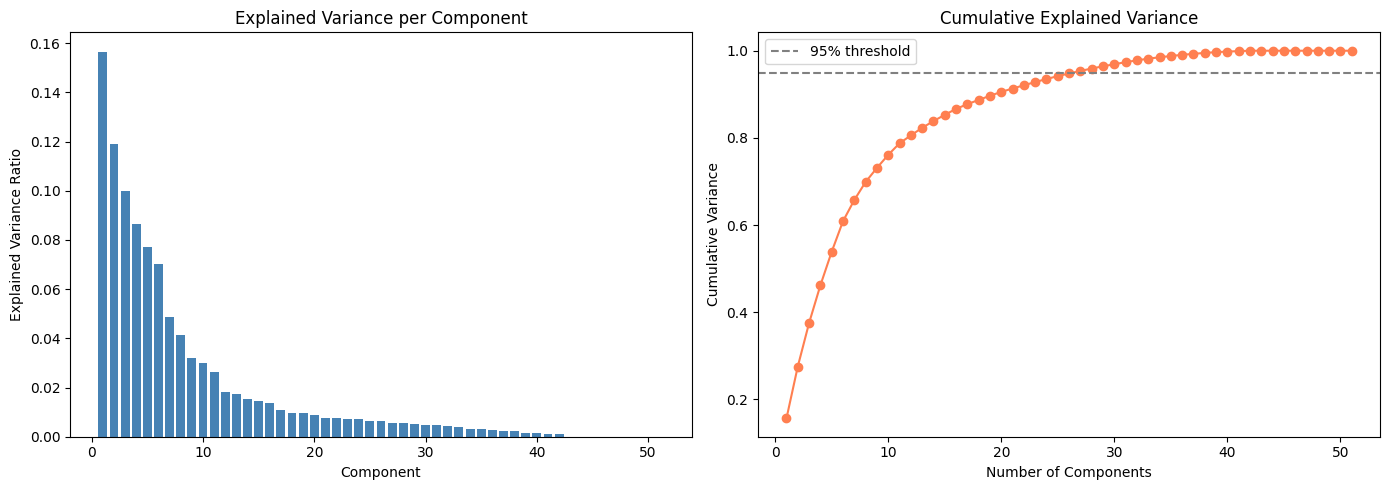

Components needed for 95% variance: 27


In [12]:
pca = PCA(random_state=SEED)
pca.fit(X_train_proc)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
axes[0].set_title('Explained Variance per Component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o', color='coral')
axes[1].axhline(0.95, ls='--', color='gray', label='95% threshold')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components_95}')

### I.2 PCA 2D Projection (colored by target)

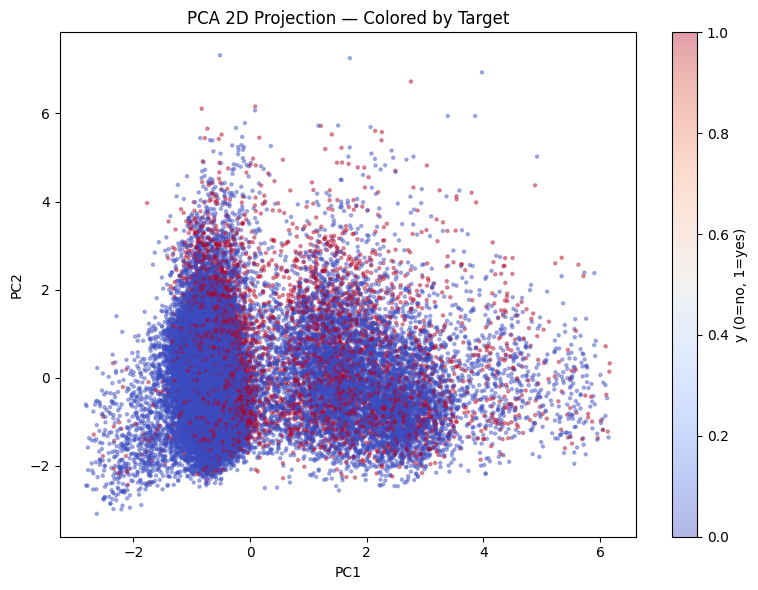

In [13]:
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca = pca_2d.fit_transform(X_train_proc)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.4, s=5)
plt.colorbar(scatter, label='y (0=no, 1=yes)')
plt.title('PCA 2D Projection — Colored by Target')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

### I.3 K-Means Clustering — Elbow & Silhouette

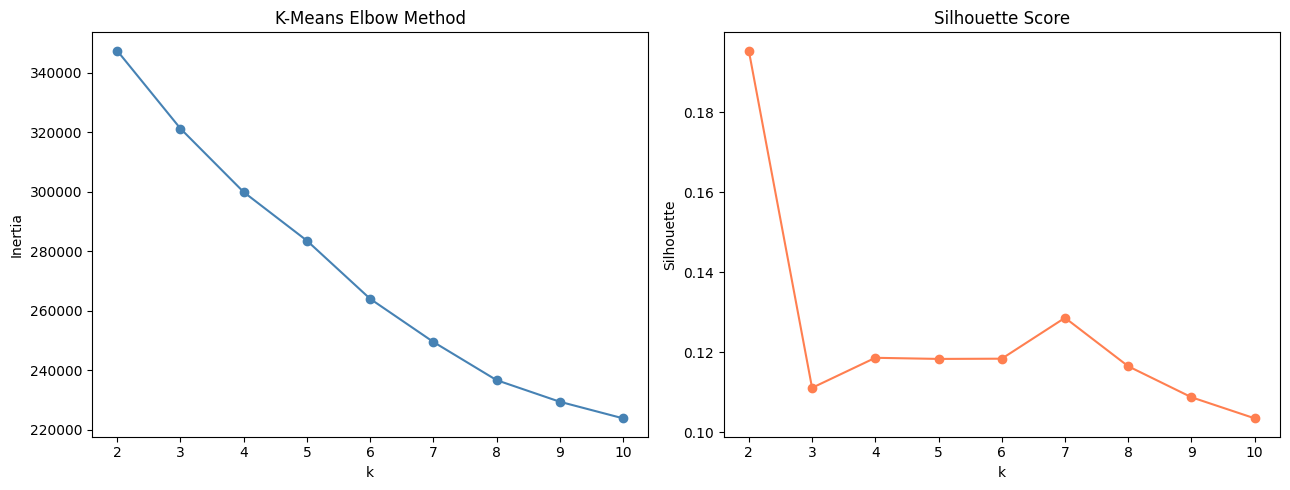

Best k by silhouette: 2


In [14]:
# Use reduced PCA space for clustering efficiency
pca_for_clust = PCA(n_components=n_components_95, random_state=SEED)
X_pca_clust = pca_for_clust.fit_transform(X_train_proc)

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_clust, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('K-Means Elbow Method')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouettes)]
print(f'Best k by silhouette: {best_k}')

### I.4 GMM Clustering

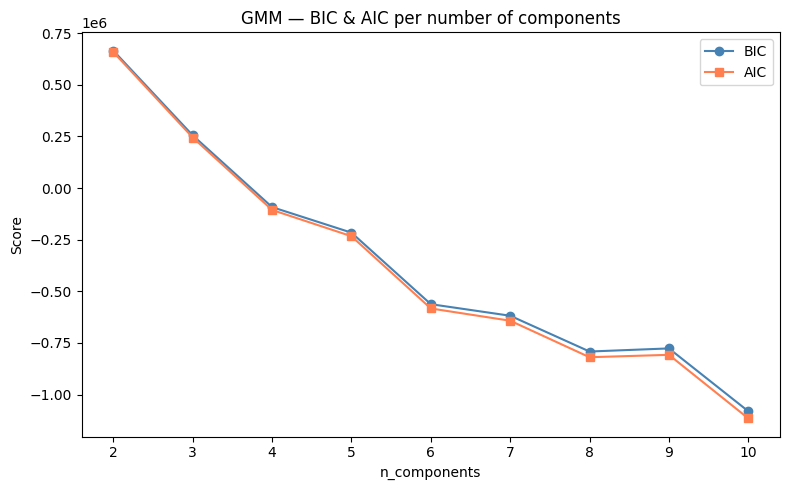

Best k by BIC: 10


In [15]:
bics, aics = [], []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=SEED)
    gmm.fit(X_pca_clust)
    bics.append(gmm.bic(X_pca_clust))
    aics.append(gmm.aic(X_pca_clust))

plt.figure(figsize=(8, 5))
plt.plot(k_range, bics, marker='o', label='BIC', color='steelblue')
plt.plot(k_range, aics, marker='s', label='AIC', color='coral')
plt.title('GMM — BIC & AIC per number of components')
plt.xlabel('n_components'); plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best k by BIC: {k_range[np.argmin(bics)]}')

### I.5 Cluster vs Target Alignment

Positive rate per cluster:
cluster
0    0.251681
1    0.152046
Name: y, dtype: float64


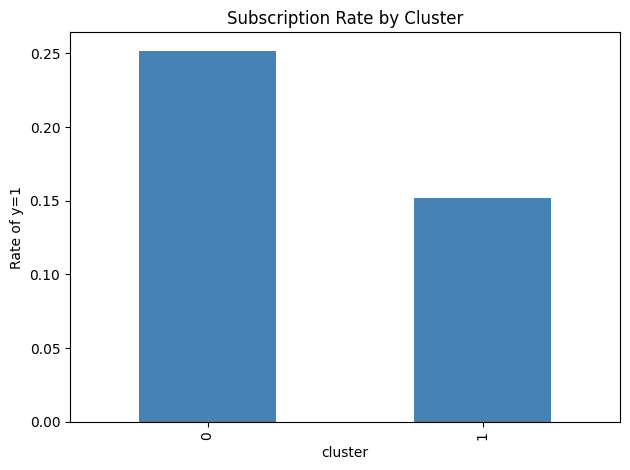

In [16]:
km_best = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
km_labels = km_best.fit_predict(X_pca_clust)

alignment_df = pd.DataFrame({'cluster': km_labels, 'y': y_train.values})
ct = alignment_df.groupby('cluster')['y'].mean()
print('Positive rate per cluster:')
print(ct)
ct.plot(kind='bar', color='steelblue', title='Subscription Rate by Cluster')
plt.ylabel('Rate of y=1')
plt.tight_layout()
plt.show()

---
## Phase II — Linear and Regularized Models

### II.1 Baseline Model (Mandatory)

In [17]:
dummy = DummyClassifier(strategy='stratified', random_state=SEED)
dummy.fit(X_train_proc, y_train)
y_pred_dummy = dummy.predict(X_test_proc)

print('=== Baseline (Stratified Dummy) ===')
print(classification_report(y_test, y_pred_dummy))

=== Baseline (Stratified Dummy) ===
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      7457
           1       0.17      0.17      0.17      1586

    accuracy                           0.71      9043
   macro avg       0.50      0.50      0.50      9043
weighted avg       0.71      0.71      0.71      9043



### II.2 Logistic Regression — Effect of Regularization (C)

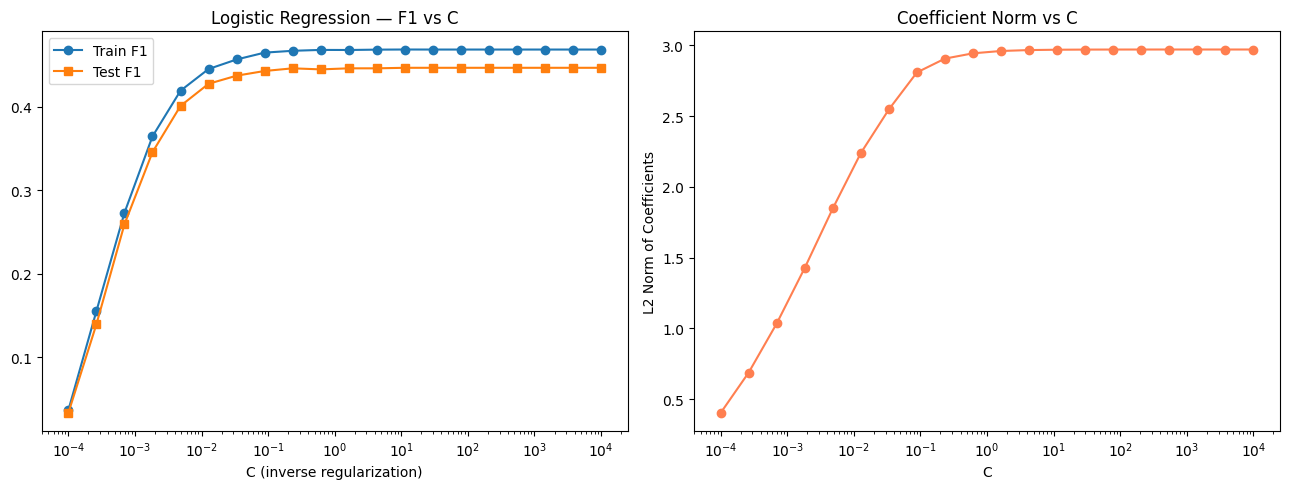

In [18]:
C_values = np.logspace(-4, 4, 20)
train_scores, test_scores, coef_norms = [], [], []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    lr.fit(X_train_proc, y_train)
    train_scores.append(f1_score(y_train, lr.predict(X_train_proc)))
    test_scores.append(f1_score(y_test,  lr.predict(X_test_proc)))
    coef_norms.append(np.linalg.norm(lr.coef_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogx(C_values, train_scores, label='Train F1', marker='o')
axes[0].semilogx(C_values, test_scores,  label='Test F1',  marker='s')
axes[0].set_title('Logistic Regression — F1 vs C')
axes[0].set_xlabel('C (inverse regularization)')
axes[0].legend()

axes[1].semilogx(C_values, coef_norms, marker='o', color='coral')
axes[1].set_title('Coefficient Norm vs C')
axes[1].set_xlabel('C')
axes[1].set_ylabel('L2 Norm of Coefficients')
plt.tight_layout()
plt.show()

### II.3 Best Logistic Regression — Evaluation

In [19]:
best_C = C_values[np.argmax(test_scores)]
print(f'Best C: {best_C:.4f}')

lr_best = LogisticRegression(C=best_C, max_iter=1000, random_state=SEED)
lr_best.fit(X_train_proc, y_train)

print(classification_report(y_test, lr_best.predict(X_test_proc)))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_best.predict_proba(X_test_proc)[:,1]):.4f}')
print(f'AUPR:    {average_precision_score(y_test, lr_best.predict_proba(X_test_proc)[:,1]):.4f}')

Best C: 11.2884
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      7457
           1       0.63      0.34      0.45      1586

    accuracy                           0.85      9043
   macro avg       0.75      0.65      0.68      9043
weighted avg       0.83      0.85      0.83      9043

ROC-AUC: 0.8399
AUPR:    0.5479


---
## Phase III — Kernel Methods (SVM)

### III.1 SVM with Different Kernels

In [20]:
# NOTE: SVM is slow on 45k samples — use a stratified subsample for tuning
from sklearn.utils import resample

idx = resample(np.arange(len(X_train_proc)), n_samples=10000, random_state=SEED, stratify=y_train)
X_svm = X_train_proc[idx]
y_svm = y_train.iloc[idx]
print(f'SVM training subset: {X_svm.shape}')

SVM training subset: (10000, 51)


In [21]:
kernels = ['linear', 'poly', 'rbf']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=SEED)
    svm.fit(X_svm, y_svm)
    y_prob = svm.predict_proba(X_test_proc)[:, 1]
    svm_results[kernel] = {
        'F1':      f1_score(y_test, svm.predict(X_test_proc)),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'AUPR':    average_precision_score(y_test, y_prob)
    }
    print(f'{kernel.upper():8s} — F1: {svm_results[kernel]["F1"]:.4f} | AUC: {svm_results[kernel]["ROC-AUC"]:.4f}')

pd.DataFrame(svm_results).T

LINEAR   — F1: 0.3640 | AUC: 0.8348
POLY     — F1: 0.4029 | AUC: 0.7858
RBF      — F1: 0.4053 | AUC: 0.7933


,F1,ROC-AUC,AUPR
linear,0.363967,0.834780,0.534736
poly,0.402934,0.785753,0.507533
rbf,0.405310,0.793289,0.527826


### III.2 SVM Hyperparameter Tuning (Grid Search)

In [22]:
param_grid = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

gs_svm = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=SEED),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
gs_svm.fit(X_svm, y_svm)
print(f'Best SVM params: {gs_svm.best_params_}')
print(f'Best CV AUC: {gs_svm.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM params: {'C': 0.1, 'gamma': 'auto'}
Best CV AUC: 0.8493


---
## Phase IV — Ensemble Methods

### IV.1 Random Forest

In [23]:
import time

t0 = time.time()
rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train_proc, y_train)
rf_time = time.time() - t0

y_prob_rf = rf.predict_proba(X_test_proc)[:, 1]
print(f'Random Forest — Training time: {rf_time:.1f}s')
print(f'F1: {f1_score(y_test, rf.predict(X_test_proc)):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'AUPR: {average_precision_score(y_test, y_prob_rf):.4f}')

Random Forest — Training time: 1.2s
F1: 0.4554
ROC-AUC: 0.8363
AUPR: 0.5499


### IV.2 Gradient Boosting

In [24]:
t0 = time.time()
gb = GradientBoostingClassifier(n_estimators=200, random_state=SEED)
gb.fit(X_train_proc, y_train)
gb_time = time.time() - t0

y_prob_gb = gb.predict_proba(X_test_proc)[:, 1]
print(f'Gradient Boosting — Training time: {gb_time:.1f}s')
print(f'F1: {f1_score(y_test, gb.predict(X_test_proc)):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}')
print(f'AUPR: {average_precision_score(y_test, y_prob_gb):.4f}')

Gradient Boosting — Training time: 14.0s
F1: 0.5006
ROC-AUC: 0.8479
AUPR: 0.5773


### IV.3 AdaBoost

In [25]:
t0 = time.time()
ada = AdaBoostClassifier(n_estimators=200, random_state=SEED)
ada.fit(X_train_proc, y_train)
ada_time = time.time() - t0

y_prob_ada = ada.predict_proba(X_test_proc)[:, 1]
print(f'AdaBoost — Training time: {ada_time:.1f}s')
print(f'F1: {f1_score(y_test, ada.predict(X_test_proc)):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_ada):.4f}')
print(f'AUPR: {average_precision_score(y_test, y_prob_ada):.4f}')

AdaBoost — Training time: 13.5s
F1: 0.4720
ROC-AUC: 0.8449
AUPR: 0.5665


### IV.4 Feature Importance (Random Forest & Gradient Boosting)

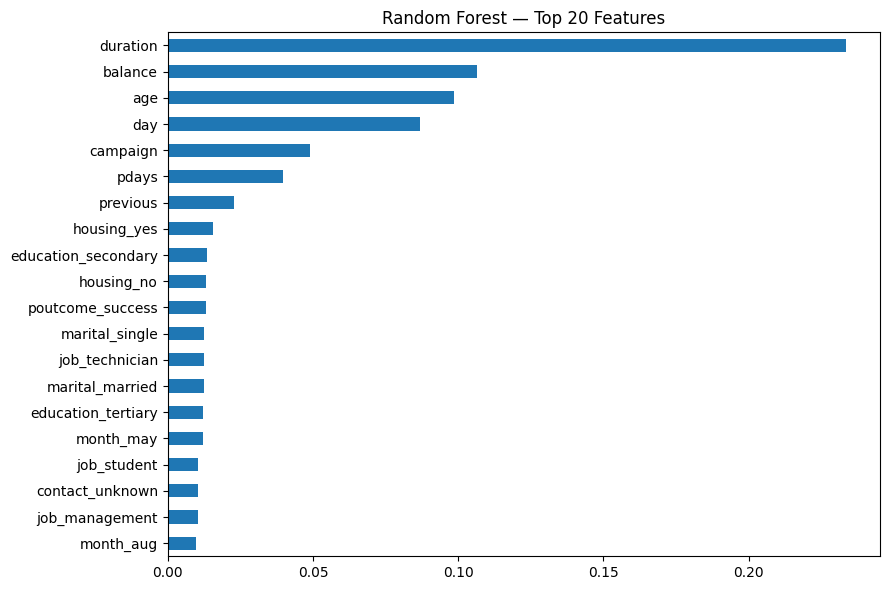

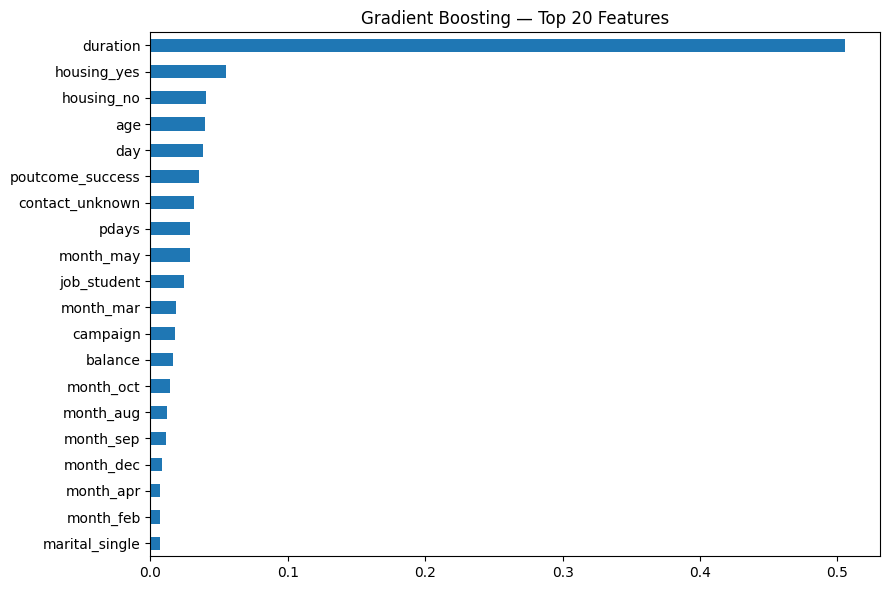

In [26]:
# Get feature names after preprocessing
ohe_names = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_features).tolist()
feature_names = num_features + ohe_names

def plot_feature_importance(model, feature_names, title, top_n=20):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.nlargest(top_n).sort_values().plot(kind='barh', figsize=(9, 6))
    plt.title(f'{title} — Top {top_n} Features')
    plt.tight_layout()
    plt.show()

plot_feature_importance(rf, feature_names, 'Random Forest')
plot_feature_importance(gb, feature_names, 'Gradient Boosting')

---
## Phase V — Model Selection and Validation

### V.1 Nested Cross-Validation

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(C=best_C, max_iter=1000, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'AdaBoost':            AdaBoostClassifier(n_estimators=200, random_state=SEED),
    'SVM (RBF)':           SVC(probability=True, random_state=SEED, **gs_svm.best_params_),
    'Baseline':            DummyClassifier(strategy='stratified', random_state=SEED)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       | AUC: 0.8470 ± 0.0049
Random Forest             | AUC: 0.8412 ± 0.0055
Gradient Boosting         | AUC: 0.8553 ± 0.0052
AdaBoost                  | AUC: 0.8522 ± 0.0065
SVM (RBF)                 | AUC: 0.8434 ± 0.0047
Baseline                  | AUC: 0.4970 ± 0.0070


### V.2 ROC Curves Comparison

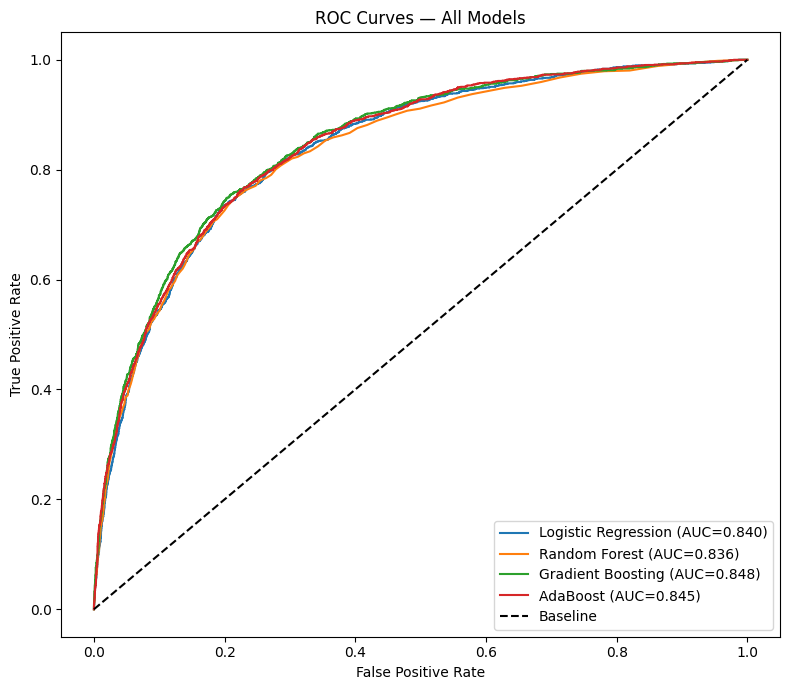

In [28]:
from sklearn.metrics import roc_curve

# Re-fit best models on full train set and plot ROC
best_models = {
    'Logistic Regression': lr_best,
    'Random Forest':       rf,
    'Gradient Boosting':   gb,
    'AdaBoost':            ada,
}

plt.figure(figsize=(8, 7))
for name, model in best_models.items():
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### V.3 Final Model Comparison Table

In [29]:
results = []
for name, model in best_models.items():
    y_pred = model.predict(X_test_proc)
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred),
        'ROC-AUC':  roc_auc_score(y_test, y_prob),
        'AUPR':     average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('ROC-AUC', ascending=False)
results_df.style.highlight_max(axis=0, color='lightgreen')

,Accuracy,F1,ROC-AUC,AUPR
Model,,,,
Gradient Boosting,0.858122,0.500584,0.847906,0.577322
AdaBoost,0.855247,0.471965,0.844914,0.566503
Logistic Regression,0.850160,0.446713,0.839938,0.547875
Random Forest,0.853478,0.455405,0.836328,0.549903


### V.4 (Optional) Paired t-test

In [30]:
from scipy.stats import ttest_rel

# Compare best two models by CV scores
model_names = list(cv_results.keys())
# Example: compare first vs second best
scores_a = cv_results[model_names[0]]
scores_b = cv_results[model_names[1]]

stat, p = ttest_rel(scores_a, scores_b)
print(f'Paired t-test: {model_names[0]} vs {model_names[1]}')
print(f'  t-statistic = {stat:.4f}, p-value = {p:.4f}')
print(f'  Significant difference: {p < 0.05}')

Paired t-test: Logistic Regression vs Random Forest
  t-statistic = 3.6658, p-value = 0.0215
  Significant difference: True


---
## 6. Conclusions

_(Write your conclusions here after running all experiments)_

- **Best model:** ...
- **Key findings from EDA:** ...
- **PCA analysis:** ...
- **Clustering insights:** ...
- **Regularization effect:** ...
- **SVM kernel comparison:** ...
- **Ensemble methods comparison:** ...
- **Class imbalance challenges:** ...
- **Limitations and future work:** ...